In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
from __future__ import annotations

import numpy as np

import mhsxtrapy
from mhsxtrapy.examples import multipole
from mhsxtrapy.plotting import plot_magnetogram, plot_field_3d

#### Example for magnetic field extrapolation from analytical boundary condition instantiated "by hand" and for all three different solutions

##### Instantiate boundary condition 

We instantiate the boundary condition manually from the analytical expression given in the following cell using the function multipole(x, y).

We choose a grid resolution of 200 in x- and y-direction (and resulting number of Fourier modes = 200) as well as resolution in z-direction of 400. We want the boundary condition to extend to 20L (= 20 Mm) in all directions. Therefore, the extrapolation will lead to a 3D data cube.

We define the normalising magnetic field strength as 500 Gauss. 

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='$x$ [Mm]', ylabel='$y$ [Mm]'>)

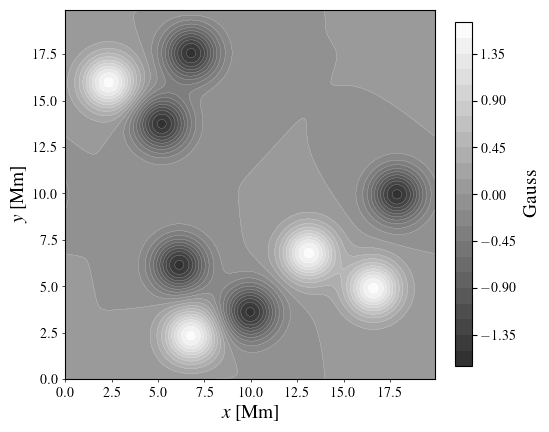

In [11]:
nx, ny = 200, 200
x = np.linspace(0.0, 2.0, nx)
y = np.linspace(0.0, 2.0, ny)
bz = np.array([[multipole(xi, yi) for xi in x] for yi in y])

data2d = mhsxtrapy.BoundaryData.from_array(bz, pixel_size=0.1, nz=400, pz=0.05)

plot_magnetogram(data2d)

##### Check if flux through boundary condition is balanced

check_fluxbalance returns the summation of the flux through the bottom boundary, normalised by the sum of absolute values. This returns a value between −1 and 1, where either extreme corresponds to the flux being directed entirely inward or entirely outward, respectively. We consider values between −0.01 and 0.01 as flux-balanced in agreement with Wiegelmann & Sakurai (2021). 

In [9]:
mhsxtrapy.is_flux_balanced(bz)

np.False_

##### Extrapolate magnetic field 

In [15]:
result_Low = mhsxtrapy.extrapolate(data2d, alpha=0.1, a=0.05, which_solution=mhsxtrapy.WhichSolution.LOW, kappa=0.01)
result_Neukirch_Wiegelmann = mhsxtrapy.extrapolate(data2d, alpha=0.1, a=0.05, b=1.0, which_solution=mhsxtrapy.WhichSolution.NEUKIRCH_WIEGELMANN, z0=2.0, deltaz=0.2)
result_Nadol_Neukirch = mhsxtrapy.extrapolate(data2d, alpha=0.1, a=0.05, b=1.0, which_solution=mhsxtrapy.WhichSolution.NADOL_NEUKIRCH, z0=2.0, deltaz=0.2)

##### Plot magnetogram

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$x$ [Mm]', zlabel='$z$ [Mm]'>)

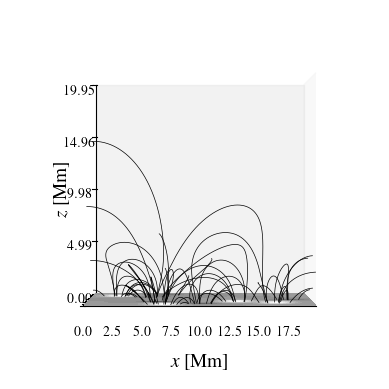

In [ ]:
fig, ax = plot_field_3d(result_Low, view="los", footpoints="active-regions", pixel_stride_x=10, pixel_stride_y=10)
fig.show()

fig, ax = plot_field_3d(result_Neukirch_Wiegelmann, view="los", footpoints="active-regions", pixel_stride_x=10, pixel_stride_y=10)
fig.show()

fig, ax = plot_field_3d(result_Nadol_Neukirch, view="los", footpoints="active-regions", pixel_stride_x=10, pixel_stride_y=10)
fig.show()